In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sqlite3
import seaborn as sns

Predicting Freight Cost
Objective: Predict freight cost for a vendor invoice using quantity and dollars, to improve cost forecasting, budgeting, and vendor negotiation.
• Freight is a non-trivial component of landed cost.
• Poor freight estimates distort margin and inventory planning.
• Automating freight estimation helps procurement teams forecast true cost before invoice arrival.

In [2]:
import pandas as pd
import sqlite3

conn = sqlite3.connect("/Users/nitin/Programming/Project/Untitled Folder 1/Data/inventory.db")

tables = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table'", conn)

print(tables)

              name
0        purchases
1  purchase_prices
2   vendor_invoice
3  begin_inventory
4    end_inventory


In [3]:
for table in tables['name']:
    print("Table name ",table)
    df= pd.read_sql_query(f"select * from {table} limit 5", conn)

Table name  purchases
Table name  purchase_prices
Table name  vendor_invoice
Table name  begin_inventory
Table name  end_inventory


In [4]:
for table in tables['name']:
    print("Table name:", table)
    
    df = pd.read_sql_query(f"SELECT * FROM {table} LIMIT 5", conn)
    
    print(df)
    print("-"*50)

Table name: purchases
           InventoryId  Store  Brand                   Description   Size  \
0    69_MOUNTMEND_8412     69   8412     Tequila Ocho Plata Fresno  750mL   
1     30_CULCHETH_5255     30   5255  TGI Fridays Ultimte Mudslide  1.75L   
2    34_PITMERDEN_5215     34   5215  TGI Fridays Long Island Iced  1.75L   
3  1_HARDERSFIELD_5255      1   5255  TGI Fridays Ultimte Mudslide  1.75L   
4    76_DONCASTER_2034     76   2034     Glendalough Double Barrel  750mL   

   VendorNumber                   VendorName  PONumber      PODate  \
0           105  ALTAMAR BRANDS LLC               8124  2023-12-21   
1          4466  AMERICAN VINTAGE BEVERAGE        8137  2023-12-22   
2          4466  AMERICAN VINTAGE BEVERAGE        8137  2023-12-22   
3          4466  AMERICAN VINTAGE BEVERAGE        8137  2023-12-22   
4           388  ATLANTIC IMPORTING COMPANY       8169  2023-12-24   

  ReceivingDate InvoiceDate     PayDate  PurchasePrice  Quantity  Dollars  \
0    2024-01-02  

In [5]:
vendor_df= pd.read_sql_query("select * from vendor_invoice",conn)
vendor_df

,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None
...,...,...,...,...,...,...,...,...,...,...
5538,9622,WEIN BAUER INC,2025-01-06,13626,2024-12-21,2025-02-10,90,1563.00,8.60,None
5539,9625,WESTERN SPIRITS BEVERAGE CO,2025-01-10,13661,2024-12-23,2025-02-18,4617,37300.48,186.50,None
5540,3664,WILLIAM GRANT & SONS INC,2025-01-02,13643,2024-12-22,2025-02-04,9848,202815.78,932.95,None
5541,9815,WINE GROUP INC,2025-01-03,13602,2024-12-20,2025-02-08,24747,149007.56,819.54,None


In [6]:
vendor_df[['Quantity','Dollars','Freight']]

,Quantity,Dollars,Freight
0,6,214.26,3.47
1,15,140.55,8.57
2,5,106.60,4.61
3,10100,137483.78,2935.20
4,1935,15527.25,429.20
...,...,...,...
5538,90,1563.00,8.60
5539,4617,37300.48,186.50
5540,9848,202815.78,932.95
5541,24747,149007.56,819.54


In [7]:
vendor_df[['Quantity','Dollars','Freight']].corr()

,Quantity,Dollars,Freight
Quantity,1.000000,0.963831,0.946550
Dollars,0.963831,1.000000,0.985141
Freight,0.946550,0.985141,1.000000


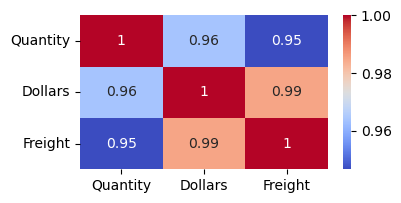

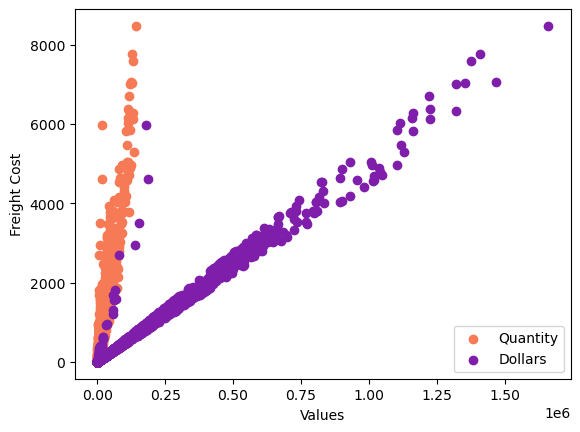

In [8]:
# Relationship between Quantity, Dollars and Freight

plt.figure(figsize=(4,2))

sns.heatmap(
    vendor_df[['Quantity','Dollars','Freight']].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.show()


# Scatter plots
plt.scatter(vendor_df['Quantity'], vendor_df['Freight'], color='#f57a55')
plt.scatter(vendor_df['Dollars'], vendor_df['Freight'], color='#7f1eaa')

plt.legend(['Quantity','Dollars'])
plt.ylabel('Freight Cost')
plt.xlabel('Values')

plt.show()

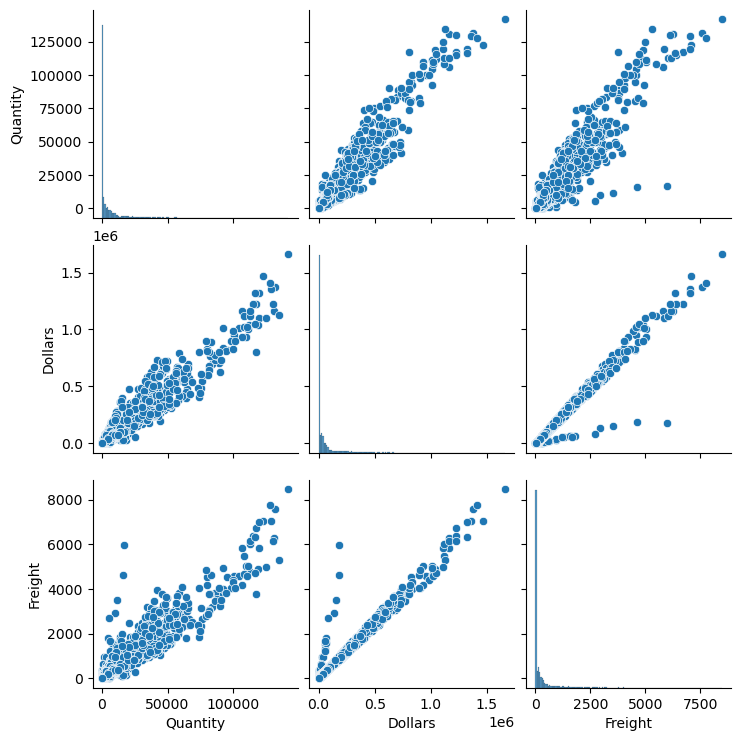

In [9]:
sns.pairplot(vendor_df[['Quantity','Dollars','Freight']])

In [10]:
# Compare high and low quantity vendors
vendor_df['freight_per_unit']=vendor_df['Freight']/vendor_df['Quantity']

In [11]:
low_quantity= vendor_df['Quantity'].quantile(0.25)
high_quantity= vendor_df['Quantity'].quantile(0.75)

In [12]:
high_quantity

np.float64(5100.5)

In [13]:
low_quantity

np.float64(83.0)

In [14]:
vendor_df.loc[vendor_df['Quantity']<low_quantity, 'freight_per_unit'] # these vendor are in low quantity

0       0.578333
1       0.571333
2       0.922000
5       0.100000
7       0.881667
          ...   
5523    0.102778
5526    0.088308
5527    0.048611
5528    0.032000
5537    0.053333
Name: freight_per_unit, Length: 1384, dtype: float64

In [15]:
vendor_df.loc[vendor_df['Quantity']<low_quantity, 'freight_per_unit'].mean()

np.float64(0.09489854253138316)

In [16]:
vendor_df.loc[vendor_df['Quantity']>high_quantity, 'freight_per_unit'].mean()

np.float64(0.049077654690759046)

In [17]:
vendor_df.loc[vendor_df['Quantity']>high_quantity, 'freight_per_unit'] # these vendor are in high quantiy

3       0.290614
14      0.183063
18      0.359743
22      0.160885
32      0.301962
          ...   
5529    0.036190
5530    0.029653
5532    0.071002
5540    0.094735
5541    0.033117
Name: freight_per_unit, Length: 1386, dtype: float64

In [60]:
x= vendor_df[['Dollars']]
y= vendor_df['Freight']

In [61]:
vendor_df.describe().round()

,VendorNumber,PONumber,Quantity,Dollars,Freight,freight_per_unit
count,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0
mean,20663.0,10889.0,6059.0,58073.0,296.0,0.0
std,34582.0,1601.0,14453.0,140234.0,714.0,0.0
min,2.0,8106.0,1.0,4.0,0.0,0.0
25%,3089.0,9504.0,83.0,968.0,5.0,0.0
50%,7240.0,10890.0,423.0,4765.0,25.0,0.0
75%,10754.0,12276.0,5100.0,44587.0,230.0,0.0
max,201359.0,13661.0,141660.0,1660436.0,8468.0,3.0


In [62]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test= train_test_split(x,y, test_size=0.2, random_state= 42)

In [63]:
x_train

,Dollars
2609,264.24
5527,342.48
5321,572.40
3805,68821.14
1215,604197.73
...,...
3772,2618.27
5191,74386.98
5226,36.96
5390,644.00


In [64]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [65]:
model1= LinearRegression()
model1.fit(x_train,y_train)

model2= DecisionTreeRegressor(max_depth=4, random_state=42)
model2.fit(x_train,y_train)

model3= RandomForestRegressor(random_state=42)
model3.fit(x_train,y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [66]:
def evaluate_model(model, X_test, y_test, model_name):
    preds = model.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)*100

    print(f"\n{model_name} Performance:")
    print(f"MAE : {mae:.2f}")
    print(f"RMSE : {rmse:.2f}")
    print(f"R2 : {r2:.2f}%")

In [67]:
evaluate_model(model1, x_test, y_test, "Linear Regression")
evaluate_model(model2, x_test, y_test, "DecisionTreeRegressor")
evaluate_model(model3, x_test, y_test, "RandomForestRegressor")


Linear Regression Performance:
MAE : 24.11
RMSE : 124.72
R2 : 96.99%

DecisionTreeRegressor Performance:
MAE : 38.12
RMSE : 138.25
R2 : 96.30%

RandomForestRegressor Performance:
MAE : 28.27
RMSE : 142.21
R2 : 96.08%


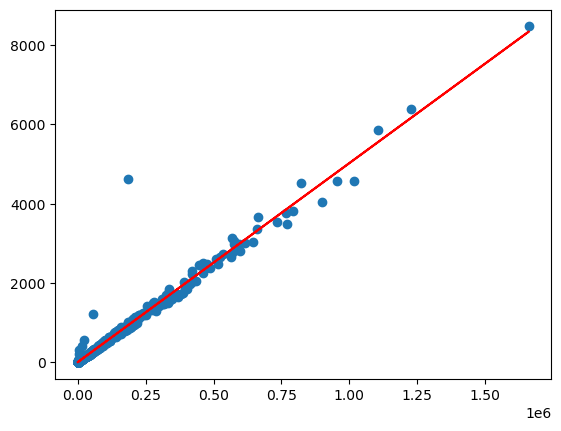

In [68]:
plt.scatter(x_test, y_test)
plt.plot(x_test, model1.predict(x_test),color='red')

In [70]:
input_data={
    "Dollars": [18500,9000],
}
df= pd.DataFrame(input_data)

In [71]:
model1.predict(df)

array([97.78868161, 50.14455838])